# NumPy-Based Exploration of Student Records

A function-driven walkthrough of `students.csv` built on NumPy **structured arrays**. Instead of loading each column into its own list, the whole file is read into a single record array, then sliced by field name.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

DATA_PATH = "/home/anupam/Downloads/students.csv"

records = np.genfromtxt(
    DATA_PATH,
    delimiter=",",
    names=True,
    dtype=None,
    encoding="utf-8",
)

print("record array shape:", records.shape)
print("fields:", records.dtype.names)
records[:5]

record array shape: (120,)
fields: ('name', 'age', 'height')


array([('Anisha Regmi', 21, 6.3), ('Amit Ghimire', 18, 6.1),
       ('Sujal Tamang', 19, 5.4), ('Amit Rai', 18, 5.5),
       ('Sabina Acharya', 25, 6.1)],
      dtype=[('name', '<U17'), ('age', '<i8'), ('height', '<f8')])

In [2]:
# Pull typed views out of the structured array once, reuse everywhere below
student_names = records["name"]
student_ages = records["age"].astype(np.float64)
student_heights = records["height"].astype(np.float64)

n_students = records.shape[0]
print(f"Loaded {n_students} student records.")

Loaded 120 student records.


## A small reusable stats helper

Rather than repeating `np.mean`, `np.median`, etc. for each column separately, one function builds a stats dictionary for any numeric array.

In [3]:
def summarize(values: np.ndarray, label: str) -> dict:
    """Return a dict of common descriptive statistics for a 1D numpy array."""
    return {
        "label": label,
        "n": values.size,
        "min": np.min(values),
        "max": np.max(values),
        "range": np.ptp(values),
        "mean": np.mean(values),
        "median": np.median(values),
        "std": np.std(values),
        "p25": np.percentile(values, 25),
        "p75": np.percentile(values, 75),
    }


def print_summary(stats: dict) -> None:
    print(f"=== {stats['label']} (n={stats['n']}) ===")
    for key in ("min", "max", "range", "mean", "median", "std", "p25", "p75"):
        print(f"  {key:>7}: {stats[key]:.3f}")


age_stats = summarize(student_ages, "Age")
height_stats = summarize(student_heights, "Height")

print_summary(age_stats)
print()
print_summary(height_stats)

=== Age (n=120) ===
      min: 18.000
      max: 25.000
    range: 7.000
     mean: 21.675
   median: 22.000
      std: 2.374
      p25: 20.000
      p75: 23.000

=== Height (n=120) ===
      min: 5.000
      max: 6.300
    range: 1.300
     mean: 5.659
   median: 5.700
      std: 0.368
      p25: 5.400
      p75: 5.900


## Percentile-based filtering

Instead of a simple "above the mean" mask, students are grouped into quartiles using `np.percentile`, which is more robust to skew.

In [4]:
def top_quartile(values: np.ndarray, names: np.ndarray, label: str):
    cutoff = np.percentile(values, 75)
    in_top = values >= cutoff
    print(f"{label} 75th percentile cutoff: {cutoff:.2f}")
    print(f"Students in the top quartile by {label.lower()} ({in_top.sum()} total):")
    for nm, val in sorted(zip(names[in_top], values[in_top]), key=lambda t: -t[1]):
        print(f"  {nm:<20} {val}")
    return in_top


top_age_mask = top_quartile(student_ages, student_names, "Age")
print()
top_height_mask = top_quartile(student_heights, student_names, "Height")

Age 75th percentile cutoff: 23.00
Students in the top quartile by age (49 total):
  Sabina Acharya       25.0
  Asmita Bhattarai     25.0
  Nabin Ghimire        25.0
  Shreya Acharya       25.0
  Rojina Acharya       25.0
  Anisha Maharjan      25.0
  Kritika Magar        25.0
  Sneha Tamang         25.0
  Prakriti Maharjan    25.0
  Sabina Bhattarai     25.0
  Bikash Maharjan      25.0
  Asmita Bhandari      25.0
  Dipesh Karki         25.0
  Aarav Thapa          25.0
  Rojina Ghimire       25.0
  Samiksha Thapa       25.0
  Puja Basnet          25.0
  Rajan Regmi          25.0
  Bibek Rai            25.0
  Sneha Rai            25.0
  Sanjana Gurung       25.0
  Prabin Bhattarai     25.0
  Dipesh Adhikari      25.0
  Kritika Tamang       25.0
  Sanjana Shrestha     24.0
  Aarav Karki          24.0
  Bikash Rai           24.0
  Sabina Regmi         24.0
  Kiran Regmi          24.0
  Dipesh Bhandari      23.0
  Anisha Magar         23.0
  Samiksha Joshi       23.0
  Sanjana Poudel      

## Ranking students

`np.argsort` on the negated array gives a descending-order ranking in one line, avoiding the separate `[::-1]` reversal step.

In [5]:
def ranked(values: np.ndarray, names: np.ndarray, top_n: int = 5, descending: bool = True):
    order = np.argsort(-values if descending else values)
    return list(zip(names[order][:top_n], values[order][:top_n]))


print("Top 5 oldest:", ranked(student_ages, student_names, descending=True))
print("Top 5 youngest:", ranked(student_ages, student_names, descending=False))
print("Top 5 tallest:", ranked(student_heights, student_names, descending=True))
print("Top 5 shortest:", ranked(student_heights, student_names, descending=False))

Top 5 oldest: [(np.str_('Sabina Acharya'), np.float64(25.0)), (np.str_('Asmita Bhattarai'), np.float64(25.0)), (np.str_('Prakriti Maharjan'), np.float64(25.0)), (np.str_('Sneha Tamang'), np.float64(25.0)), (np.str_('Rojina Acharya'), np.float64(25.0))]
Top 5 youngest: [(np.str_('Amit Ghimire'), np.float64(18.0)), (np.str_('Amit Rai'), np.float64(18.0)), (np.str_('Sneha Bhattarai'), np.float64(18.0)), (np.str_('Kiran Joshi'), np.float64(18.0)), (np.str_('Puja Rai'), np.float64(18.0))]
Top 5 tallest: [(np.str_('Anisha Regmi'), np.float64(6.3)), (np.str_('Kiran Joshi'), np.float64(6.3)), (np.str_('Dipesh Karki'), np.float64(6.3)), (np.str_('Puja Basnet'), np.float64(6.3)), (np.str_('Roshan Adhikari'), np.float64(6.2))]
Top 5 shortest: [(np.str_('Nabin Basnet'), np.float64(5.0)), (np.str_('Bikash Maharjan'), np.float64(5.0)), (np.str_('Shreya Adhikari'), np.float64(5.0)), (np.str_('Sabina KC'), np.float64(5.0)), (np.str_('Aarav Acharya'), np.float64(5.0))]


## Age frequency table via `np.bincount`

`np.unique` works fine for this, but `np.bincount` on integer-offset ages is a faster alternative worth showing: it produces a dense count array indexed by age directly.

In [6]:
int_ages = student_ages.astype(np.int64)
min_age = int_ages.min()
age_counts = np.bincount(int_ages - min_age)
age_labels = np.arange(min_age, min_age + age_counts.size)

print(f"{'Age':>5} | {'Count':>5} | Bar")
print("-" * 30)
for age_val, cnt in zip(age_labels, age_counts):
    print(f"{age_val:>5} | {cnt:>5} | {'#' * cnt}")

  Age | Count | Bar
------------------------------
   18 |    19 | ###################
   19 |     5 | #####
   20 |    17 | #################
   21 |    16 | ################
   22 |    14 | ##############
   23 |    20 | ####################
   24 |     5 | #####
   25 |    24 | ########################


## Correlation, computed manually

Rather than calling `np.corrcoef` directly, the Pearson correlation is derived from `np.cov` and `np.std` to show the underlying formula: r = cov(x, y) / (std(x) * std(y)).

In [7]:
cov_matrix = np.cov(student_ages, student_heights, ddof=0)
cov_xy = cov_matrix[0, 1]
manual_r = cov_xy / (np.std(student_ages) * np.std(student_heights))

# cross-check against the built-in function
builtin_r = np.corrcoef(student_ages, student_heights)[0, 1]

print(f"Covariance(age, height): {cov_xy:.5f}")
print(f"Manually derived r:      {manual_r:.5f}")
print(f"np.corrcoef r:           {builtin_r:.5f}")
assert np.isclose(manual_r, builtin_r), "manual and builtin correlation disagree"

Covariance(age, height): 0.07506
Manually derived r:      0.08592
np.corrcoef r:           0.08592


## Combined visualization grid

All four plots are drawn as subplots of a single figure with `plt.subplots(2, 2)` rather than as four separate figures.

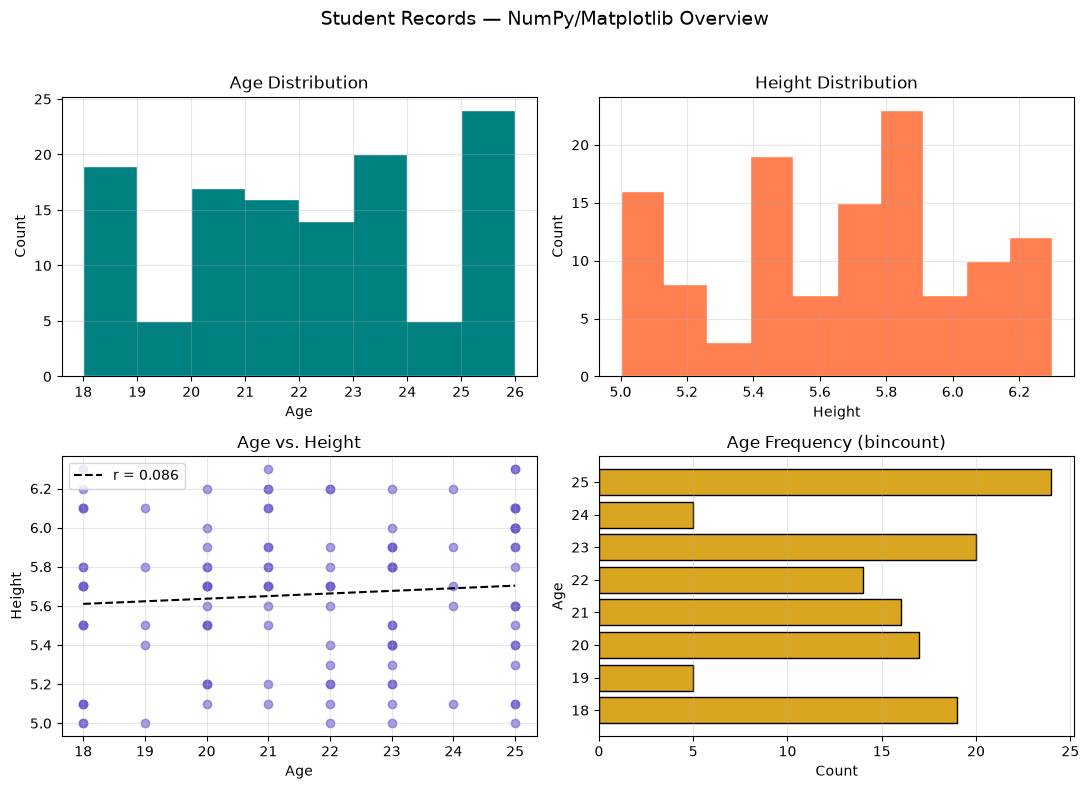

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle("Student Records — NumPy/Matplotlib Overview", fontsize=14)

# Top-left: age histogram
axes[0, 0].hist(student_ages, bins=np.arange(student_ages.min(), student_ages.max() + 2),
                 color="teal", edgecolor="white", histtype="stepfilled")
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(alpha=0.3)

# Top-right: height histogram
axes[0, 1].hist(student_heights, bins=10, color="coral", edgecolor="white", histtype="stepfilled")
axes[0, 1].set_title("Height Distribution")
axes[0, 1].set_xlabel("Height")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha=0.3)

# Bottom-left: age vs height scatter + fit
axes[1, 0].scatter(student_ages, student_heights, color="slateblue", alpha=0.6)
slope, intercept = np.polyfit(student_ages, student_heights, 1)
x_line = np.linspace(student_ages.min(), student_ages.max(), 100)
axes[1, 0].plot(x_line, slope * x_line + intercept, color="black", linestyle="--",
                 label=f"r = {builtin_r:.3f}")
axes[1, 0].set_title("Age vs. Height")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Height")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Bottom-right: age counts as a horizontal bar chart (different orientation)
axes[1, 1].barh(age_labels, age_counts, color="goldenrod", edgecolor="black")
axes[1, 1].set_title("Age Frequency (bincount)")
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_ylabel("Age")
axes[1, 1].grid(alpha=0.3, axis="x")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Final report

In [9]:
report_lines = [
    "STUDENT DATA REPORT",
    "=" * 40,
    f"Students analyzed : {n_students}",
    f"Age   : mean={age_stats['mean']:.2f}, std={age_stats['std']:.2f}, "
    f"range=[{age_stats['min']:.0f}, {age_stats['max']:.0f}]",
    f"Height: mean={height_stats['mean']:.2f}, std={height_stats['std']:.2f}, "
    f"range=[{height_stats['min']:.1f}, {height_stats['max']:.1f}]",
    f"Age-Height correlation (r): {builtin_r:.3f}",
    f"Top quartile by age: {top_age_mask.sum()} students",
    f"Top quartile by height: {top_height_mask.sum()} students",
]
print("\n".join(report_lines))

STUDENT DATA REPORT
Students analyzed : 120
Age   : mean=21.68, std=2.37, range=[18, 25]
Height: mean=5.66, std=0.37, range=[5.0, 6.3]
Age-Height correlation (r): 0.086
Top quartile by age: 49 students
Top quartile by height: 39 students
